In [263]:
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [264]:
df = pd.read_csv("results/boot_results_diagnosis.csv")
df = df.drop(columns=["pred_file", "rel_path", "auc_std", "status"])

df

,dataset,model,strategy,n,auroc,ci_low,ci_high,is_ood,model_family,model_type
0,Camelyon17,BLIP2-2.7b,ZS,920,0.517506,0.479656,0.555933,1,CLIP,general
1,Camelyon17,BLIP2-2.7b,FT-LoRA,920,0.982731,0.975661,0.988340,1,CLIP,general
2,Camelyon17,BLIP2-2.7b,FT-LP,920,0.981502,0.974411,0.987425,1,CLIP,general
3,Camelyon17,BioMedCLIP,ZS,920,0.772451,0.741732,0.802931,0,CLIP,medical
4,Camelyon17,BioMedCLIP,FT-LoRA,920,0.987067,0.981275,0.992037,0,CLIP,medical
...,...,...,...,...,...,...,...,...,...,...
139,PAPILA,PubMedCLIP,FT-LoRA,56,0.791376,0.650911,0.910884,1,CLIP,medical
140,PAPILA,PubMedCLIP,FT-LP,56,0.514518,0.316622,0.729200,1,CLIP,medical
141,PAPILA,SigLIP,ZS,56,0.520777,0.313030,0.730567,1,SigLIP,general
142,PAPILA,SigLIP,FT-LoRA,56,0.715907,0.548388,0.877552,1,SigLIP,general


In [265]:
df["model_family"].unique()

array(['CLIP', 'SigLIP'], dtype=object)

# heatmap

In [266]:
df["dataset+strategy"] = df["dataset"] + "-" + df["strategy"]

model_order = [
    "CLIP",
    "BLIP2-2.7b",
    "MedCLIP",
    "PLIP",
    "PubMedCLIP",
    "BioMedCLIP",
    "SigLIP",
    "MedSigLIP",
]

data_order = [
    "CheXpert-ZS",
    "CheXpert-FT-LP",
    "Camelyon17-ZS",
    "Camelyon17-FT-LP",
    "HAM10000-ZS",
    "HAM10000-FT-LP",
    "PAPILA-ZS",
    "PAPILA-FT-LP",
    "GF3300-ZS",
    "GF3300-FT-LP",
    "HarvardFairVLMed10k-ZS",
    "HarvardFairVLMed10k-FT-LP",
]

metric = "auroc"
df_plot = df.copy(deep=True)

df_plot[metric] = df_plot[metric] * 100

data_heatmap = df_plot.pivot(index="model", columns="dataset+strategy", values=metric)
data_heatmap = data_heatmap.reindex(model_order, axis=0)
data_heatmap = data_heatmap.reindex(data_order, axis=1)
data_heatmap

dataset+strategy,CheXpert-ZS,CheXpert-FT-LP,Camelyon17-ZS,Camelyon17-FT-LP,HAM10000-ZS,HAM10000-FT-LP,PAPILA-ZS,PAPILA-FT-LP,GF3300-ZS,GF3300-FT-LP,HarvardFairVLMed10k-ZS,HarvardFairVLMed10k-FT-LP
model,,,,,,,,,,,,
CLIP,40.763420,82.231394,52.970573,96.798124,46.430547,83.888575,59.610628,75.761746,47.599752,79.084897,58.049974,68.387275
BLIP2-2.7b,57.028723,86.123080,51.750582,98.150158,54.129027,87.630057,39.947443,86.670612,36.875093,81.072811,39.228951,71.832104
MedCLIP,90.470717,86.876323,76.445484,81.773540,48.761601,73.580938,36.519160,81.290296,38.074845,71.019628,52.119074,61.118053
PLIP,46.738167,84.884037,74.449780,98.531012,45.737658,84.343276,52.074482,67.312171,36.330492,78.153054,46.209983,69.194387
PubMedCLIP,76.606316,84.287141,33.006155,95.588260,41.251621,84.136450,37.908390,51.451840,41.375830,77.070212,46.007937,69.102619
BioMedCLIP,60.573625,88.537878,77.245080,98.582262,56.760734,86.550356,75.949703,71.954659,47.903321,81.738564,54.355978,71.823157
SigLIP,53.398070,85.345382,59.807128,97.214046,46.943388,87.348251,52.077676,71.060571,55.295044,77.218707,53.030129,71.431121
MedSigLIP,62.487500,88.943405,42.184180,98.603079,52.549076,86.227444,56.950833,87.763656,54.461928,76.451632,59.651566,73.515878


In [267]:
mask = df_plot.pivot(
    index="model", columns="dataset+strategy", values="is_ood")
mask = mask.reindex(model_order, axis=0)
mask = mask.reindex(data_order, axis=1)
mask

dataset+strategy,CheXpert-ZS,CheXpert-FT-LP,Camelyon17-ZS,Camelyon17-FT-LP,HAM10000-ZS,HAM10000-FT-LP,PAPILA-ZS,PAPILA-FT-LP,GF3300-ZS,GF3300-FT-LP,HarvardFairVLMed10k-ZS,HarvardFairVLMed10k-FT-LP
model,,,,,,,,,,,,
CLIP,1,1,1,1,1,1,1,1,1,1,1,1
BLIP2-2.7b,1,1,1,1,1,1,1,1,1,1,1,1
MedCLIP,0,0,1,1,1,1,1,1,1,1,1,1
PLIP,1,1,0,0,1,1,1,1,1,1,1,1
PubMedCLIP,0,0,1,1,1,1,1,1,1,1,1,1
BioMedCLIP,0,0,0,0,0,0,0,0,1,1,1,1
SigLIP,1,1,1,1,1,1,1,1,1,1,1,1
MedSigLIP,0,0,0,0,0,0,0,0,1,1,1,1


In [268]:
mask.shape

(8, 12)

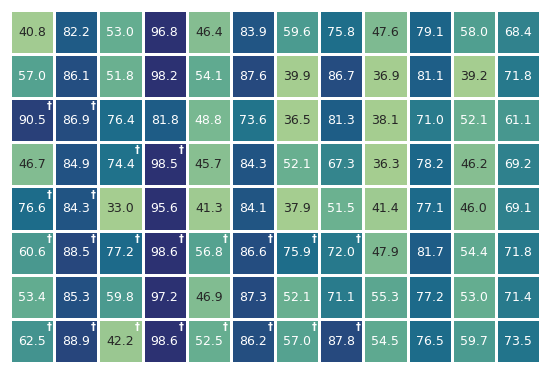

In [269]:
def prepare_annot_for_heatmap(data):
    annot = np.array(data).copy()
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            annot[i, j] = "{:.1f}".format(float(annot[i, j]))
    return annot


scale = 0.7
fig, ax = plt.subplots(figsize=(mask.shape[0] * scale, mask.shape[1] * scale))

heat = sns.heatmap(
    data_heatmap,
    cbar=False,
    cmap=sns.color_palette("crest", as_cmap=True),
    annot=prepare_annot_for_heatmap(data_heatmap),
    ax=ax,
    yticklabels=False,
    xticklabels=False,
    fmt="",
    square=True,
    linewidths=3 * scale,
    annot_kws={"size": 9},
    vmin=40,
    vmax=95,
)

mask = np.array(mask).astype(bool)


# Add asterisks to the specified cells
for i in range(data_heatmap.shape[0]):
    for j in range(data_heatmap.shape[1]):
        if not mask[i, j]:  # Check if the cell is marked for asterisk
            ax.text(
                j + 0.88,  # Adjust position slightly to the right of the cell
                i + 0.18,  # Center vertically
                "†",
                color="white",  # Asterisk color (contrast with heatmap)
                fontsize=7,
                ha="center",
                va="center",
                weight="bold",
            )

ax.tick_params(right=False, left=True, labelleft=False)
# ax.set_yticks(np.arange(8) + 0.5)
# ax.set_xticks(np.arange(12) + 0.5)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(
    "figures/diagnosis_heatmap",
    dpi=400,
    bbox_inches="tight",
)

# plt.show()

# family-wise comparison

In [270]:
datasets = ["CheXpert", "Camelyon17", "HAM10000", "PAPILA", "GF3300", "HarvardFairVLMed10k"]
model_familis = {
    "SigLIP": ["MedSigLIP", "SigLIP"],
    "CLIP": ["MedCLIP", "PLIP", "PubMedCLIP", "BioMedCLIP", "CLIP", "BLIP2-2.7b"],
}

palette = sns.color_palette("Set2", len(datasets))
color_dict = dict(zip(datasets, palette))

color_dict

{'CheXpert': (0.4, 0.7607843137254902, 0.6470588235294118),
 'Camelyon17': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 'HAM10000': (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 'PAPILA': (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 'GF3300': (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 'HarvardFairVLMed10k': (1.0, 0.8509803921568627, 0.1843137254901961)}

In [271]:
df["model"].unique()

array(['BLIP2-2.7b', 'BioMedCLIP', 'CLIP', 'MedCLIP', 'MedSigLIP', 'PLIP',
       'PubMedCLIP', 'SigLIP'], dtype=object)

In [272]:
def get_general_medical_df_sub(df, rq, family):
    df_sub = df.loc[(df["strategy"].isin(["ZS", "FT-LP"])) & (df["model_family"] == family)]
    if rq == 1:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["strategy"] == "ZS")]
        df_sub_medical = df_sub.loc[(df_sub["model_type"] == "medical") & (df_sub["strategy"] == "ZS")]
    elif rq == 2:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["strategy"] == "FT-LP")]
        df_sub_medical = df_sub.loc[
            (df_sub["model_type"] == "medical") & (df_sub["strategy"] == "ZS") & (df_sub["is_ood"] == 0)
        ]
    elif rq == 3:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["strategy"] == "FT-LP")]
        df_sub_medical = df_sub.loc[
            (df_sub["model_type"] == "medical") & (df_sub["strategy"] == "FT-LP") & (df_sub["is_ood"] == 1)
        ]

    df_sub = pd.concat([df_sub_general, df_sub_medical]).reset_index(drop=True)
    df_sub = df_sub.loc[df_sub["dataset"].isin(df_sub_medical["dataset"].unique())]

    return df_sub, df_sub_general, df_sub_medical

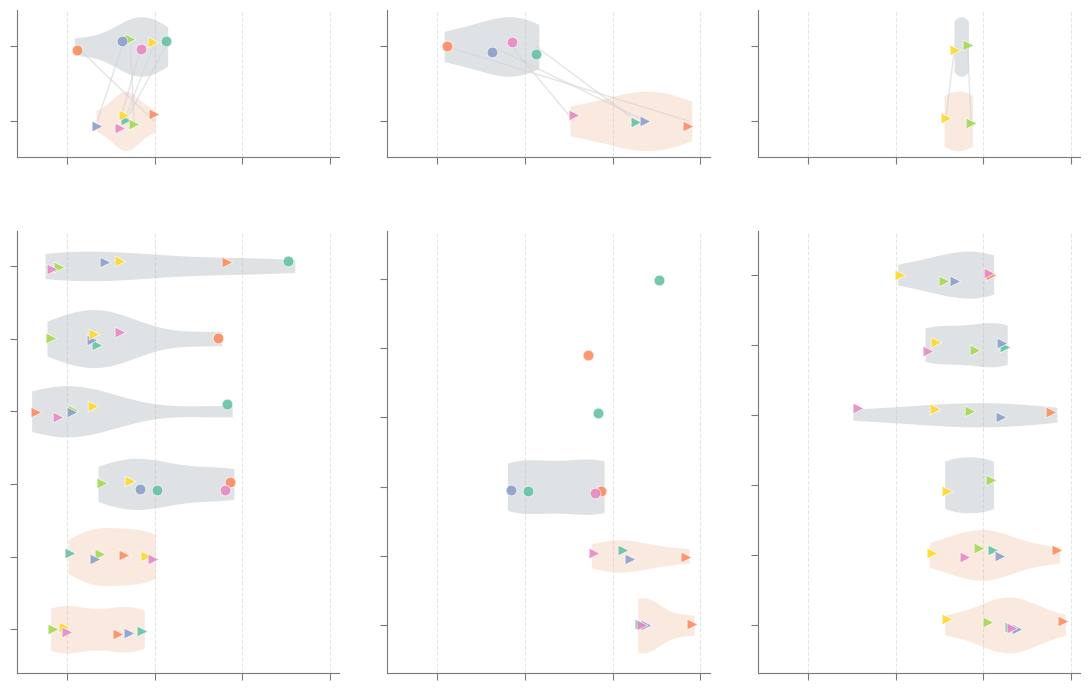

In [300]:
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon

fig, axes = plt.subplots(2, 3, figsize=(11, 7), gridspec_kw={"height_ratios": [2, 6]}, sharex=True)

# 淡色 violin 颜色
violin_palette = {
    "medical": "#cfd8dc",  # 淡蓝灰
    "general": "#ffe0cc",  # 淡橙灰
}

for rq in range(1, 4):
    for idx_family, family in enumerate(model_familis.keys()):
        cur_ax = axes[idx_family, rq - 1]

        df_sub, df_sub_general, df_sub_medical = get_general_medical_df_sub(df, rq, family)

        #  ================================
        # 排序：medical(Set1)在上，general(Set2)在下
        # ================================
        # 不同模型名称顺序
        model_order = model_familis[family]

        # 不同dataset
        datasets_unique = df_sub["dataset"].unique()

        # ================================
        # 1️⃣ Violin 分两次画（按model_type）
        # ================================
        for mtype in ["medical", "general"]:
            df_tmp = df_sub[df_sub["model_type"] == mtype]

            if len(df_tmp) > 0:
                sns.violinplot(
                    data=df_tmp,
                    y="model",
                    x="auroc",
                    order=model_order,
                    ax=cur_ax,
                    inner=None,
                    linewidth=0,
                    color=violin_palette[mtype],
                    cut=0.1,
                    alpha=0.7,
                )

        # ================================
        # 2️⃣ Scatter + y轴 jitter
        # ================================
        y_positions = {model: i for i, model in enumerate(model_order)}

        for d in datasets_unique:
            df_d = df_sub[df_sub["dataset"] == d]

            for _, row in df_d.iterrows():
                y_base = y_positions[row["model"]]

                # 加小幅 jitter
                y_jitter = y_base + np.random.uniform(-0.1, 0.1)

                is_ood = row["is_ood"]

                marker_style = "o" if is_ood == 0 else ">"

                cur_ax.scatter(
                    row["auroc"],
                    y_jitter,
                    color=color_dict[d],
                    s=60,
                    alpha=0.9,
                    zorder=3,
                    marker=marker_style,
                    edgecolor="white",
                    linewidth=0.5,
                )

        # ================================
        # 3️⃣ 两模型时加 paired 线
        # ================================
        if len(model_order) == 2:
            for d in datasets_unique:
                df_d = df_sub[df_sub["dataset"] == d].sort_values("model")
                if len(df_d) == 2:
                    y0 = y_positions[df_d.iloc[0]["model"]]
                    y1 = y_positions[df_d.iloc[1]["model"]]

                    cur_ax.plot(
                        df_d["auroc"].values,
                        [y0, y1],
                        color="lightgray",
                        alpha=0.6,
                        linewidth=1,
                        zorder=1,
                    )

        # ================================
        # 美化
        # ================================
        cur_ax.set_xlabel("")
        cur_ax.set_ylabel("")
        # cur_ax.set_title(f"{family} - RQ{rq}")

        cur_ax.grid(axis="x", linestyle="--", alpha=0.3)
        # cur_ax.grid(axis="y", linestyle="--", alpha=0.3)

        cur_ax.spines["top"].set_visible(False)
        # cur_ax.spines["bottom"].set_visible(False)
        cur_ax.spines["right"].set_visible(False)

        cur_ax.spines["bottom"].set_color("#777b7e")
        cur_ax.spines["left"].set_color("#777b7e")
        cur_ax.spines["bottom"].set_linewidth(0.8)
        cur_ax.spines["left"].set_linewidth(0.8)

        cur_ax.set_xticks([0.4, 0.6, 0.8, 1])
        cur_ax.set_xticklabels([])
        cur_ax.set_yticklabels([])

        cur_ax.tick_params(
            axis="both",  # x 和 y 都设置
            which="both",  # major + minor
            direction="out",  # 向外
            length=5,  # tick 长度
            width=0.8,  # tick 线宽
            colors="#777b7e",  # tick 颜色
        )

        # break

    # break


plt.tight_layout()
fig.subplots_adjust(hspace=0.25, wspace=0.15)

plt.savefig(
    "figures/diagnosis_family_compare",
    dpi=400,
    bbox_inches="tight",
)

In [191]:
for rq in range(1, 4):
    for idx_family, family in enumerate(model_familis.keys()):
        df_sub, df_sub_general, df_sub_medical = get_general_medical_df_sub(
            df, rq, family)

        # ================================
        # LMM
        # ================================

        # 只保留 medical/general
        df_lmm = df_sub.copy()

        # 确保分类变量
        df_lmm["model_type"] = df_lmm["model_type"].astype("category")

        # 设定 reference = medical（可改）
        df_lmm["model_type"] = df_lmm["model_type"].cat.reorder_categories(
            ["medical", "general"], ordered=True)

        # Mixed model
        model = smf.mixedlm("auroc ~ model_type", df_lmm,
                            groups=df_lmm["dataset"])

        result = model.fit()

        beta = result.params["model_type[T.general]"]
        ci_low, ci_high = result.conf_int().loc["model_type[T.general]"]
        p_value = result.pvalues["model_type[T.general]"]

        print("\n" + "-" * 40)
        print(f"{family} - RQ{rq}")
        print(f"β = {beta:.3f}")
        print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}]")
        print(f"p = {p_value:.4f}")

        # ================================
        # paired p value
        # ================================

        model_order = model_familis[family]
        # 1️⃣ 设置有序 categorical
        df_sub["model"] = pd.Categorical(
            df_sub["model"], categories=model_order, ordered=True)

        # 2️⃣ 排序 dataframe
        df_sub = df_sub.sort_values("model")

        medical_models = df_sub[df_sub["model_type"]
                                == "medical"]["model"].unique()
        general_models = df_sub[df_sub["model_type"]
                                == "general"]["model"].unique()

        # 初始化矩阵
        p_matrix = pd.DataFrame(
            np.nan, index=medical_models, columns=general_models)

        annot_matrix = pd.DataFrame(
            "", index=medical_models, columns=general_models)

        for m_med in medical_models:
            for m_gen in general_models:

                df_med = df_sub[df_sub["model"] == m_med][["dataset", "auroc"]]
                df_gen = df_sub[df_sub["model"] == m_gen][["dataset", "auroc"]]

                df_pair = df_med.merge(
                    df_gen, on="dataset", suffixes=("_med", "_gen"))

                n_pair = len(df_pair)

                if n_pair >= 2:
                    stat, p = wilcoxon(
                        df_pair["auroc_med"], df_pair["auroc_gen"])

                    p_matrix.loc[m_med, m_gen] = p
                    annot_matrix.loc[m_med, m_gen] = f"p={p:.3f} n={n_pair}"
                else:
                    annot_matrix.loc[m_med, m_gen] = f"n={n_pair}"

        print(annot_matrix)

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbench


----------------------------------------
SigLIP - RQ1
β = -0.013
95% CI = [-0.079, 0.053]
p = 0.7015
                SigLIP
MedSigLIP  p=0.562 n=6

----------------------------------------
CLIP - RQ1
β = -0.052
95% CI = [-0.142, 0.038]
p = 0.2590
                   CLIP   BLIP2-2.7b
MedCLIP     p=0.844 n=6  p=0.312 n=6
PLIP        p=0.688 n=6  p=0.688 n=6
PubMedCLIP  p=0.438 n=6  p=1.000 n=6
BioMedCLIP  p=0.094 n=6  p=0.031 n=6

----------------------------------------
SigLIP - RQ2
β = 0.317
95% CI = [0.182, 0.452]
p = 0.0000
                SigLIP
MedSigLIP  p=0.125 n=4

----------------------------------------
CLIP - RQ2
β = 0.143
95% CI = [0.048, 0.238]
p = 0.0031
                   CLIP   BLIP2-2.7b
MedCLIP             n=1          n=1
PLIP                n=1          n=1
PubMedCLIP          n=1          n=1
BioMedCLIP  p=0.250 n=4  p=0.125 n=4

----------------------------------------
SigLIP - RQ3
β = -0.007
95% CI = [-0.035, 0.021]
p = 0.6440
                SigLIP
MedSigLIP  p=

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [192]:
df_pair

,dataset,auroc_med,auroc_gen
0,GF3300,0.817386,0.810728
1,HarvardFairVLMed10k,0.718232,0.718321


# cross-family test

In [369]:
def try_fetch(list, index):
    try:
        return list[index]
    except:
        return None


def get_med_stats(df, metric):
    assert len(df["dataset"].unique()) == 1
    dataset = df["dataset"].unique()[0]

    df_med = df.loc[df["model_type"] == "medical"]
    df_zs = df_med.loc[(df_med["strategy"] == "ZS")]
    df_sft = df_med.loc[(df_med["strategy"] == "FT-LP") & (df_med["is_ood"] == 1)]

    zs_metric = np.sort(
        np.array(df_zs[metric]),
    )
    sft_metric = np.sort(
        np.array(df_sft[metric]),
    )
    best_zs, second_zs = try_fetch(zs_metric, -1), try_fetch(zs_metric, -2)
    best_sft, second_sft = try_fetch(sft_metric, -1), try_fetch(sft_metric, -2)

    return (best_zs, second_zs), (best_sft, second_sft)


def update_min(current_min, value):
    return min(current_min, value)


def update_max(current_max, value):
    return max(current_max, value)


def build_fake_bootstrap(df, n_samples=1000):
    rows = []

    for _, row in df.iterrows():
        mean = row["auroc"]
        ci_low = row["ci_low"]
        ci_high = row["ci_high"]

        # 估计标准差
        std = (ci_high - ci_low) / (2 * 1.96)

        samples = np.random.normal(mean, std, n_samples)

        for s in samples:
            new_row = row.copy()
            new_row["auroc"] = s
            rows.append(new_row)

    return pd.DataFrame(rows)


def generate_gradient(hex_color, n=6):
    """
    从深色生成 n 个从浅到深的颜色渐变（hex 格式）
    """
    import matplotlib.colors as mcolors
    import numpy as np

    # 深色 RGB
    deep_rgb = np.array(mcolors.to_rgb(hex_color))

    # 生成从白色到深色的线性插值
    colors = []
    for i in np.linspace(0.0, 1.0, n):
        rgb = (1 - i) * np.array([1, 1, 1]) + i * deep_rgb
        colors.append(mcolors.to_hex(rgb))
    return colors[1:5] + [colors[-1]]

/tmp/ipykernel_2239382/939893423.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["auroc"] *= 100
/tmp/ipykernel_2239382/939893423.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["ci_low"] *= 100
/tmp/ipykernel_2239382/939893423.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing

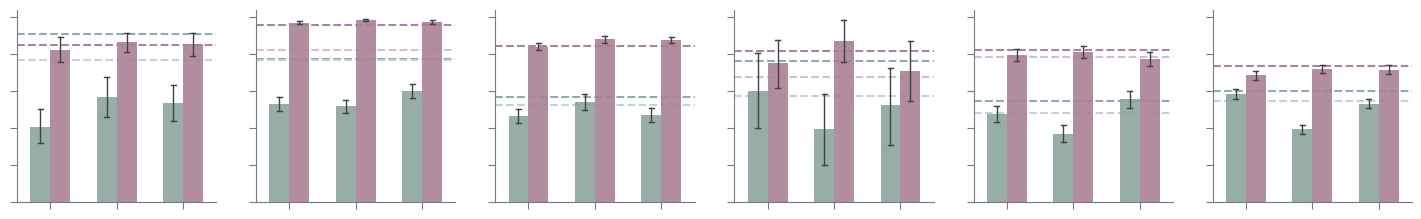

In [370]:
data_order = ["CheXpert", "Camelyon17", "HAM10000",
              "PAPILA", "GF3300", "HarvardFairVLMed10k"]

model_order = [
    "CLIP",
    "BLIP2-2.7b",
    "SigLIP",
]

metric = "auroc"

fig, axes = plt.subplots(1, 6, figsize=(18, 2.5), sharey=True)

for i_plot, dataset in enumerate(data_order):
    cur_ax = axes[i_plot]

    df_plot = df.loc[(df["dataset"] == dataset) & (
        df["strategy"].isin(["ZS", "FT-LP"]))]
    df_plot["auroc"] *= 100
    df_plot["ci_low"] *= 100
    df_plot["ci_high"] *= 100

    min_value, max_value = df_plot[metric].min(), df_plot[metric].max()
    (best_med_zs, second_med_zs), (best_med_sft,
                                   second_med_sft) = get_med_stats(df_plot, metric)

    if best_med_zs is not None:
        min_value = update_min(min_value, best_med_zs)
        max_value = update_max(max_value, best_med_zs)
        cur_ax.axhline(y=best_med_zs, color=generate_gradient(
            "#5c898e")[4], ls="--", lw=1.5, zorder=1, alpha=0.7)
    if second_med_zs is not None:
        min_value = update_min(min_value, second_med_zs)
        max_value = update_max(max_value, second_med_zs)
        cur_ax.axhline(y=second_med_zs, color=generate_gradient(
            "#5c898e")[1], ls="--", lw=1.5, zorder=1, alpha=0.9)
    if best_med_sft is not None:
        min_value = update_min(min_value, best_med_sft)
        max_value = update_max(max_value, best_med_sft)
        cur_ax.axhline(y=best_med_sft, color=generate_gradient(
            "#80517a")[4], ls="--", lw=1.5, zorder=1, alpha=0.7)
    if second_med_sft is not None:
        if abs(best_med_sft - second_med_sft) > 3:
            min_value = update_min(min_value, second_med_sft)
            max_value = update_max(max_value, second_med_sft)
            cur_ax.axhline(
                y=second_med_sft, color=generate_gradient("#80517a")[1], ls="--", lw=1.5, zorder=1, alpha=0.9
            )

    min_ylim, max_ylim = int(min_value / 10) * \
        10, (int(max_value / 10) + 1) * 10
    max_ylim = min(100, max_ylim)

    df_general = df_plot.loc[(df_plot["model_type"] == "general") & (
        df_plot["strategy"].isin(["ZS", "FT-LP"]))]
    df_general["model"] = pd.Categorical(
        df_general["model"], categories=model_order, ordered=True)
    df_general = df_general.sort_values(by="model")

    df_boot = build_fake_bootstrap(df_general)

    sns.barplot(
        data=df_boot,
        x="model",
        y="auroc",
        hue="strategy",
        hue_order=["ZS", "FT-LP"],
        errorbar=("pi", 95),  # ✅ percentile interval
        err_kws={"linewidth": 1},
        n_boot=0,  # ✅ 不再重新bootstrap
        ax=cur_ax,
        palette=["#86aaa0", "#b17a96"],
        legend=False,
        capsize=0.15,
        width=0.6,
        gap=0,
        alpha=0.9,
    )

    # ================================
    # 美化
    # ================================
    cur_ax.set_xlabel("")
    cur_ax.set_ylabel("")
    # cur_ax.set_title(f"{family} - RQ{rq}")

    # cur_ax.grid(axis="y", linestyle="--", alpha=0.3)

    cur_ax.spines["top"].set_visible(False)
    # cur_ax.spines["bottom"].set_visible(False)
    cur_ax.spines["right"].set_visible(False)

    cur_ax.spines["bottom"].set_color("#777b7e")
    cur_ax.spines["left"].set_color("#777b7e")
    cur_ax.spines["bottom"].set_linewidth(0.8)
    cur_ax.spines["left"].set_linewidth(0.8)

    # cur_ax.set_xticks([0.4, 0.6, 0.8, 1])
    cur_ax.set_xticklabels([])
    cur_ax.set_yticklabels([])

    cur_ax.tick_params(
        axis="both",  # x 和 y 都设置
        which="both",  # major + minor
        direction="out",  # 向外
        length=5,  # tick 长度
        width=0.8,  # tick 线宽
        colors="#777b7e",  # tick 颜色
    )

plt.subplots_adjust(wspace=0.2)
plt.savefig(
    "figures/diagnosis_cross_family_bar.png",
    dpi=1000,
    bbox_inches="tight",
)

In [341]:
df_general

,dataset,model,strategy,n,auroc,ci_low,ci_high,is_ood,model_family,model_type,dataset+strategy
102,HarvardFairVLMed10k,CLIP,ZS,1746,58.049974,55.306282,60.612516,1,CLIP,general,HarvardFairVLMed10k-ZS
104,HarvardFairVLMed10k,CLIP,FT-LP,1746,68.387275,65.922129,70.796237,1,CLIP,general,HarvardFairVLMed10k-FT-LP
96,HarvardFairVLMed10k,BLIP2-2.7b,ZS,1746,39.228951,36.488801,41.806819,1,CLIP,general,HarvardFairVLMed10k-ZS
98,HarvardFairVLMed10k,BLIP2-2.7b,FT-LP,1746,71.832104,69.413687,74.169385,1,CLIP,general,HarvardFairVLMed10k-FT-LP
117,HarvardFairVLMed10k,SigLIP,ZS,1746,53.030129,50.321074,55.551310,1,SigLIP,general,HarvardFairVLMed10k-ZS
119,HarvardFairVLMed10k,SigLIP,FT-LP,1746,71.431121,68.955997,73.730947,1,SigLIP,general,HarvardFairVLMed10k-FT-LP


In [337]:
get_med_stats(df_plot, metric)

((np.float64(90.47071672526855), np.float64(76.60631604683455)),
 (np.float64(84.88403687052288), None))

In [360]:
generate_gradient("#5c898e")

['#dee7e8', '#bed0d2', '#9db8bb', '#7da1a5', '#5c898e']

In [339]:
row

dataset                   CheXpert
model                         CLIP
strategy                     FT-LP
n                              234
auroc                    82.231394
ci_low                   75.057952
ci_high                  88.877418
is_ood                           1
model_family                  CLIP
model_type                 general
dataset+strategy    CheXpert-FT-LP
Name: 32, dtype: object

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Accuracy
No. Observations: 36      Method:             REML    
No. Groups:       6       Scale:              0.0002  
Min. group size:  6       Log-Likelihood:     90.4626 
Max. group size:  6       Converged:          Yes     
Mean group size:  6.0                                 
------------------------------------------------------
             Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    0.776    0.010 78.935 0.000  0.757  0.796
Set[T.Set2]  0.027    0.004  6.047 0.000  0.018  0.035
Group Var    0.001    0.029                           



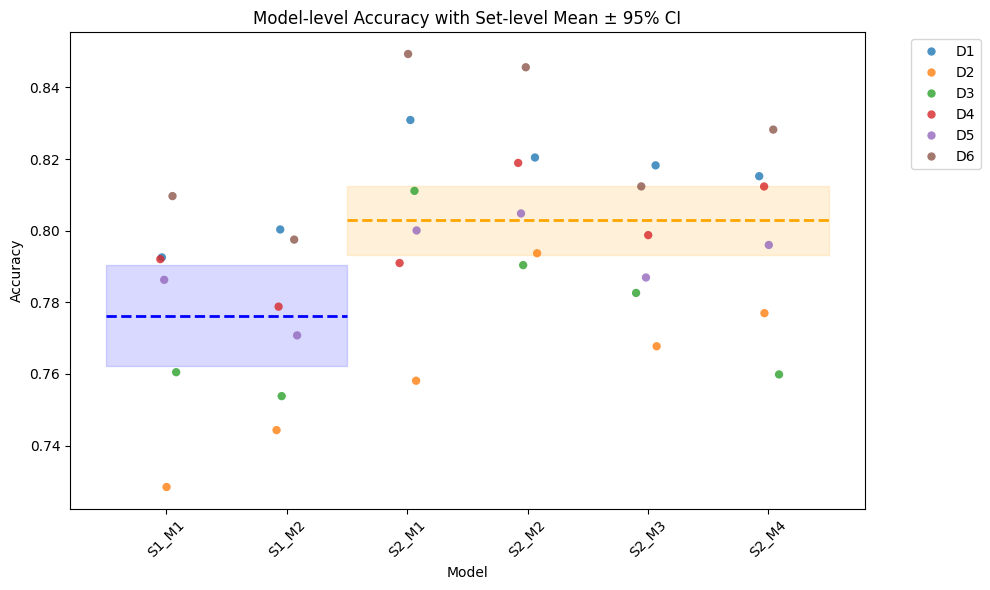

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

np.random.seed(42)

# -----------------------------
# 1. 模拟数据
# -----------------------------


set1_models = ["S1_M1", "S1_M2"]
set2_models = ["S2_M1", "S2_M2", "S2_M3", "S2_M4"]

rows = []

for d in datasets:
    dataset_effect = np.random.normal(0, 0.015)

    # Set1 baseline
    for m in set1_models:
        model_effect = np.random.normal(0, 0.01)
        acc = 0.78 + dataset_effect + model_effect + np.random.normal(0, 0.01)
        rows.append([d, "Set1", m, acc])

    # Set2 slightly better
    for m in set2_models:
        model_effect = np.random.normal(0, 0.01)
        acc = 0.81 + dataset_effect + model_effect + np.random.normal(0, 0.01)
        rows.append([d, "Set2", m, acc])

df = pd.DataFrame(rows, columns=["Dataset", "Set", "Model", "Accuracy"])

# -----------------------------
# 2. Linear Mixed Model
# -----------------------------
# 随机效应：Dataset
# 固定效应：Set

model = smf.mixedlm("Accuracy ~ Set", df, groups=df["Dataset"])

result = model.fit()

print(result.summary())

# -----------------------------
# 3. 计算 set-level mean + CI
# -----------------------------

set_summary = df.groupby("Set")["Accuracy"].agg(["mean", "std", "count"])
set_summary["se"] = set_summary["std"] / np.sqrt(set_summary["count"])
set_summary["ci_low"] = set_summary["mean"] - 1.96 * set_summary["se"]
set_summary["ci_high"] = set_summary["mean"] + 1.96 * set_summary["se"]

# -----------------------------
# 4. 绘图
# -----------------------------

plt.figure(figsize=(10, 6))

# 散点：x=Model, y=Accuracy, 颜色=Dataset
sns.stripplot(data=df, x="Model", y="Accuracy", hue="Dataset", dodge=False, size=6, alpha=0.8)

# 画 set-level mean ± CI 背景带
x_positions = range(len(df["Model"].unique()))
models = df["Model"].unique()

for set_name in set_summary.index:
    mean = set_summary.loc[set_name, "mean"]
    ci_low = set_summary.loc[set_name, "ci_low"]
    ci_high = set_summary.loc[set_name, "ci_high"]

    if set_name == "Set1":
        xmin, xmax = -0.5, 1.5
        color = "blue"
    else:
        xmin, xmax = 1.5, 5.5
        color = "orange"

    plt.fill_between([xmin, xmax], ci_low, ci_high, color=color, alpha=0.15)

    plt.hlines(mean, xmin, xmax, colors=color, linestyles="--", linewidth=2)

plt.title("Model-level Accuracy with Set-level Mean ± 95% CI")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
df

,Dataset,Set,Model,Accuracy
0,D1,Set1,S1_M1,0.792545
1,D1,Set1,S1_M2,0.800339
2,D1,Set2,S2_M1,0.830901
3,D1,Set2,S2_M2,0.820430
4,D1,Set2,S2_M3,0.818242
5,D1,Set2,S2_M4,0.815213
6,D2,Set1,S1_M1,0.728429
7,D2,Set1,S1_M2,0.744315
8,D2,Set2,S2_M1,0.758098
9,D2,Set2,S2_M2,0.793700
